## Model Training and comparison - Hour

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("Libraries imported.")

Libraries imported.


In [3]:
# Load the feature-engineered hourly dataset
df = pd.read_csv('hour_dataset_featured_new.csv')

print("Dataset loaded.")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded.
Shape: (17379, 25)


,atemp,day_sin,holiday,hr_cos,hr_sin,hum,humidity_windspeed,is_peak_hour,is_weekend,mnth_cos,...,temp_squared,time_of_day_evening,time_of_day_morning,weathersit_3,weekday_cos,weekday_sin,windspeed,workingday,yr,cnt
0,0.2879,0.201299,0,1.000000,0.000000,0.81,0.0,0,1,0.866025,...,0.0576,0,0,0,0.62349,-0.781831,0.0,0,0,16
1,0.2727,0.201299,0,0.965926,0.258819,0.80,0.0,0,1,0.866025,...,0.0484,0,0,0,0.62349,-0.781831,0.0,0,0,40
2,0.2727,0.201299,0,0.866025,0.500000,0.80,0.0,0,1,0.866025,...,0.0484,0,0,0,0.62349,-0.781831,0.0,0,0,32
3,0.2879,0.201299,0,0.707107,0.707107,0.75,0.0,0,1,0.866025,...,0.0576,0,0,0,0.62349,-0.781831,0.0,0,0,13
4,0.2879,0.201299,0,0.500000,0.866025,0.75,0.0,0,1,0.866025,...,0.0576,0,0,0,0.62349,-0.781831,0.0,0,0,1


In [4]:
print("Info:")
print(df.info())
print("\nDescribe:")
print(df.describe())
print("\nMissing values:")
print(df.isnull().sum())

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   atemp                17379 non-null  float64
 1   day_sin              17379 non-null  float64
 2   holiday              17379 non-null  int64  
 3   hr_cos               17379 non-null  float64
 4   hr_sin               17379 non-null  float64
 5   hum                  17379 non-null  float64
 6   humidity_windspeed   17379 non-null  float64
 7   is_peak_hour         17379 non-null  int64  
 8   is_weekend           17379 non-null  int64  
 9   mnth_cos             17379 non-null  float64
 10  mnth_sin             17379 non-null  float64
 11  season_4             17379 non-null  int64  
 12  temp                 17379 non-null  float64
 13  temp_comfort         17379 non-null  float64
 14  temp_humidity        17379 non-null  float64
 15  temp_squared         17379 non

In [5]:
target_col = 'cnt'
assert target_col in df.columns, f"Target column '{target_col}' not found. Available: {df.columns.tolist()}"

X = df.drop(columns=[target_col])
y = df[target_col]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features for algorithms that need it (Linear Regression, SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 13903, Test size: 3476


## Linear Regression

In [7]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print(f"MSE: {lr_mse:.2f}")
print(f"RMSE: {lr_rmse:.2f}")
print(f"MAE: {lr_mae:.2f}")
print(f"R²: {lr_r2:.4f}\n")

Linear Regression
MSE: 11051.45
RMSE: 105.13
MAE: 78.27
R²: 0.6510



##  Random Forest Regressor

In [8]:
rf = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print(f"MSE: {rf_mse:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"MAE: {rf_mae:.2f}")
print(f"R²: {rf_r2:.4f}\n")

Random Forest
MSE: 1716.53
RMSE: 41.43
MAE: 25.19
R²: 0.9458



## XGBoost Regressor

In [9]:
## XGBoost Regressor

xgb_model = xgb.XGBRegressor(n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost")
print(f"MSE: {xgb_mse:.2f}")
print(f"RMSE: {xgb_rmse:.2f}")
print(f"MAE: {xgb_mae:.2f}")
print(f"R²: {xgb_r2:.4f}\n")

XGBoost
MSE: 1394.99
RMSE: 37.35
MAE: 23.89
R²: 0.9559



In [10]:
# Save trained XGBoost model to pickle
import pickle

model_path = "xgb_hour_new.pkl"
with open(model_path, "wb") as f:
    pickle.dump(xgb_model, f)

print(f"Saved XGBoost model to {model_path}")

Saved XGBoost model to xgb_hour_new.pkl


## LightGBM Regressor


In [11]:
## LightGBM Regressor

lgb_model = lgb.LGBMRegressor(n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
lgb_model.fit(X_train, y_train)

lgb_pred = lgb_model.predict(X_test)

lgb_mse = mean_squared_error(y_test, lgb_pred)
lgb_rmse = np.sqrt(lgb_mse)
lgb_mae = mean_absolute_error(y_test, lgb_pred)
lgb_r2 = r2_score(y_test, lgb_pred)

print("LightGBM")
print(f"MSE: {lgb_mse:.2f}")
print(f"RMSE: {lgb_rmse:.2f}")
print(f"MAE: {lgb_mae:.2f}")
print(f"R²: {lgb_r2:.4f}\n")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003474 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1159
[LightGBM] [Info] Number of data points in the train set: 13903, number of used features: 24
[LightGBM] [Info] Start training from score 190.577070
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

## Gradient Boosting Regressor


In [12]:
## Gradient Boosting Regressor

gb_model = GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42)
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_mse = mean_squared_error(y_test, gb_pred)
gb_rmse = np.sqrt(gb_mse)
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting")
print(f"MSE: {gb_mse:.2f}")
print(f"RMSE: {gb_rmse:.2f}")
print(f"MAE: {gb_mae:.2f}")
print(f"R²: {gb_r2:.4f}\n")

Gradient Boosting
MSE: 1420.05
RMSE: 37.68
MAE: 23.93
R²: 0.9552



Comparison Table:

            Model          MSE       RMSE       MAE       R²
Linear Regression 11051.446909 105.125862 78.273889 0.650993
    Random Forest  1716.526466  41.430984 25.186565 0.945792
          XGBoost  1394.987915  37.349537 23.889887 0.955946
         LightGBM  1502.030102  38.756033 25.076194 0.952566
Gradient Boosting  1420.045941  37.683497 23.930422 0.955155


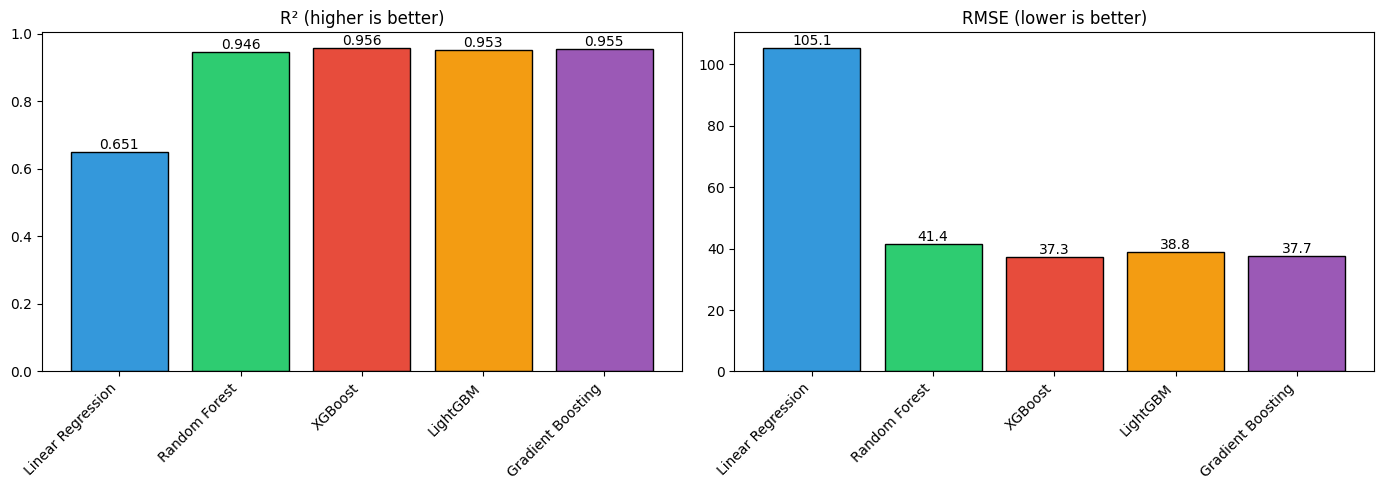


Best model: XGBoost
R²: 0.9559, RMSE: 37.35


In [13]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'Gradient Boosting'],
    'MSE': [lr_mse, rf_mse, xgb_mse, lgb_mse, gb_mse],
    'RMSE': [lr_rmse, rf_rmse, xgb_rmse, lgb_rmse, gb_rmse],
    'MAE': [lr_mae, rf_mae, xgb_mae, lgb_mae, gb_mae],
    'R²': [lr_r2, rf_r2, xgb_r2, lgb_r2, gb_r2]
})

print("Comparison Table:\n")
print(comparison.to_string(index=False))

# Bar plots
plt.figure(figsize=(14,5))
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

plt.subplot(1,2,1)
bars = plt.bar(comparison['Model'], comparison['R²'], color=colors, edgecolor='black')
plt.title('R² (higher is better)')
plt.xticks(rotation=45, ha='right')
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h, f"{h:.3f}", ha='center', va='bottom')

plt.subplot(1,2,2)
bars = plt.bar(comparison['Model'], comparison['RMSE'], color=colors, edgecolor='black')
plt.title('RMSE (lower is better)')
plt.xticks(rotation=45, ha='right')
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h, f"{h:.1f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

best_idx = comparison['R²'].idxmax()
best_model = comparison.loc[best_idx, 'Model']
best_r2 = comparison.loc[best_idx, 'R²']
best_rmse = comparison.loc[best_idx, 'RMSE']

print("\nBest model:", best_model)
print(f"R²: {best_r2:.4f}, RMSE: {best_rmse:.2f}")

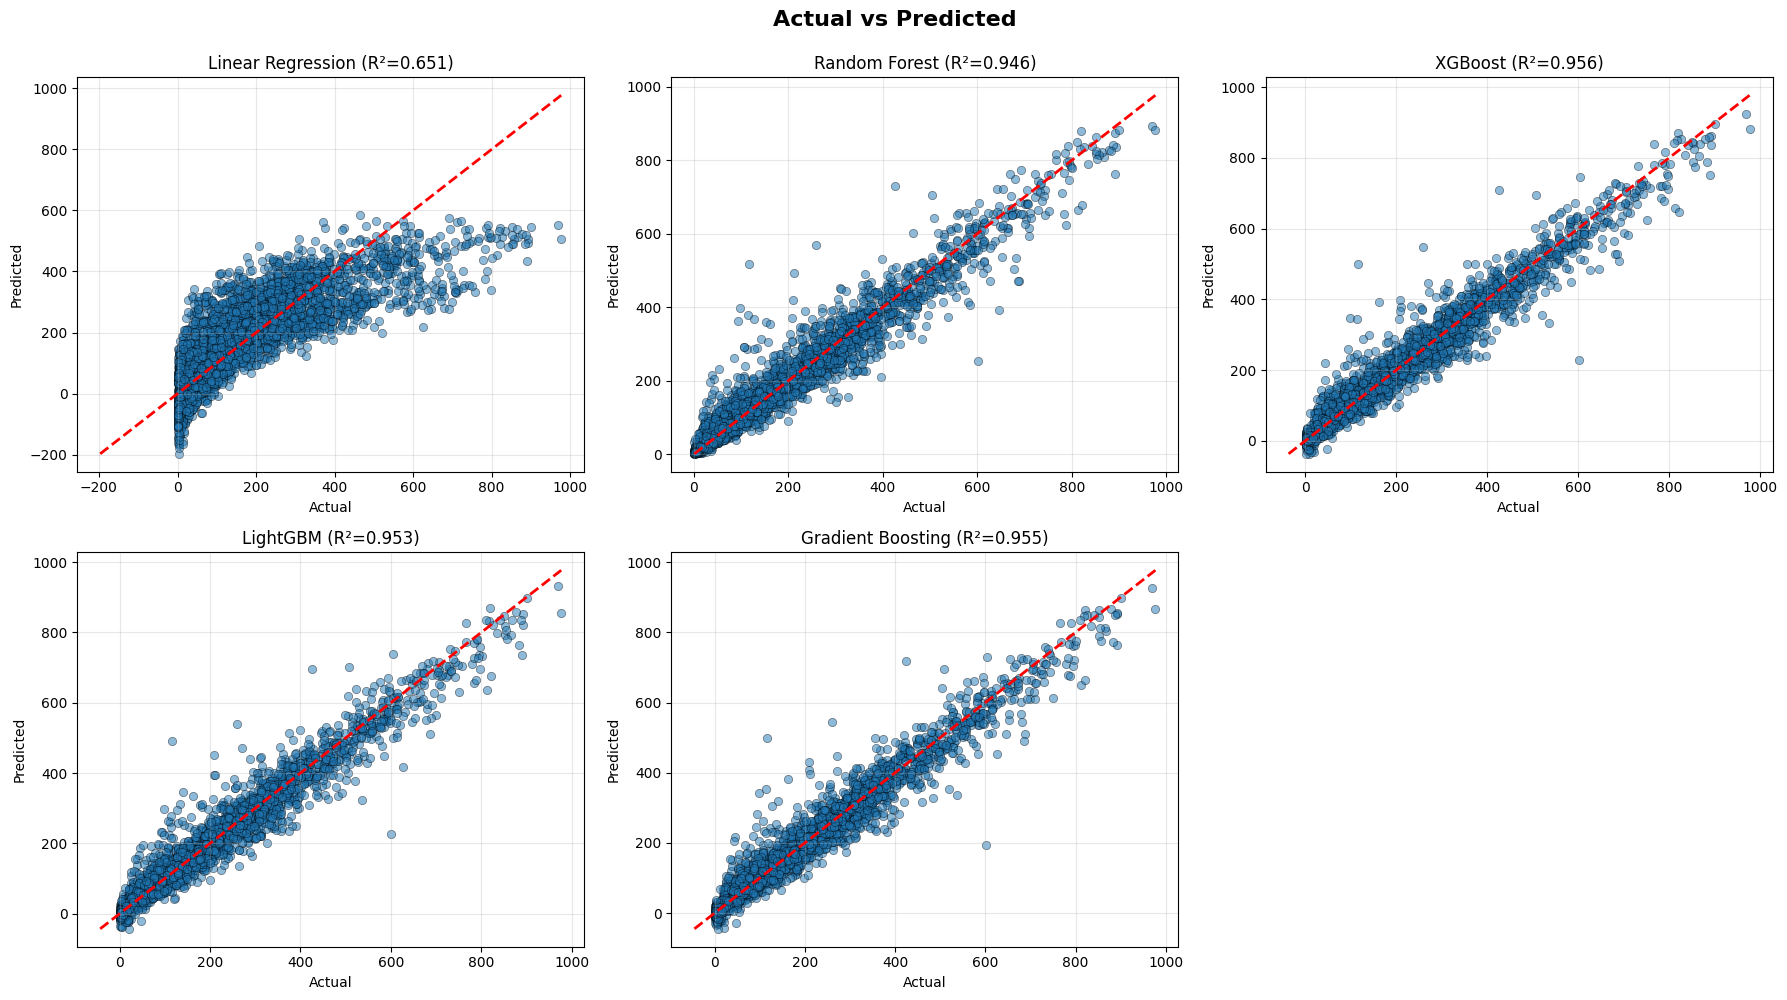

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Actual vs Predicted', fontsize=16, fontweight='bold', y=0.995)

models_preds = [
    ('Linear Regression', lr_pred, lr_r2),
    ('Random Forest', rf_pred, rf_r2),
    ('XGBoost', xgb_pred, xgb_r2),
    ('LightGBM', lgb_pred, lgb_r2),
    ('Gradient Boosting', gb_pred, gb_r2)
]

for i, (name, preds, r2) in enumerate(models_preds):
    ax = axes[i // 3, i % 3]
    ax.scatter(y_test, preds, alpha=0.5, edgecolors='black', linewidth=0.5)
    mn = min(y_test.min(), preds.min())
    mx = max(y_test.max(), preds.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=2)
    ax.set_title(f"{name} (R²={r2:.3f})")
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.grid(alpha=0.3)

axes[1, 2].axis('off')

plt.tight_layout()
plt.show()